# Constant gm Bias current gen  
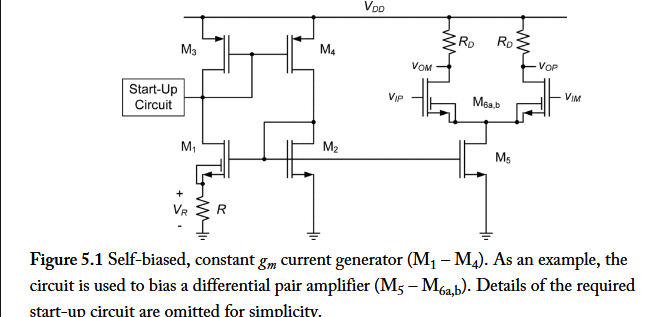 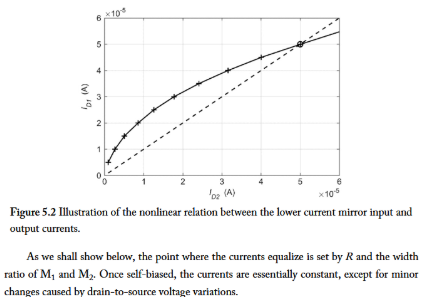

## Import libs

In [1]:
import numpy as np
import scipy.constants as sc
import matplotlib.pyplot as plt
from pygmid import Lookup as lk
from scipy.interpolate import interp1d
from scipy.interpolate import CubicSpline
pmos4 = lk('../../lookup_table/035/pmos4.mat')
nmos4 = lk('../../lookup_table/035/nmos4.mat')
import sys; sys.path.append('../..')
import adri
# Interpolation function
def interp1(x, y, value):
    # Perform cubic interpolation using interp1d
    f = interp1d(x, y, kind='cubic')
    return f(value)

## Set Specification / constraints

In [2]:
#Design Spec 
s = {
    'VDD' : 2.7,
    'ID' : 50e-6,
    'VR' : 0.1,
}
d = {
    'L12': 2
}

## Get design param

In [3]:
m1,m2,m3 = adri.constant_gm_bias(nmos4,pmos4, s, d)
adri.print_design_summary(s, d,{}, {}, m1,m2,m3)

## Flat function to see plot

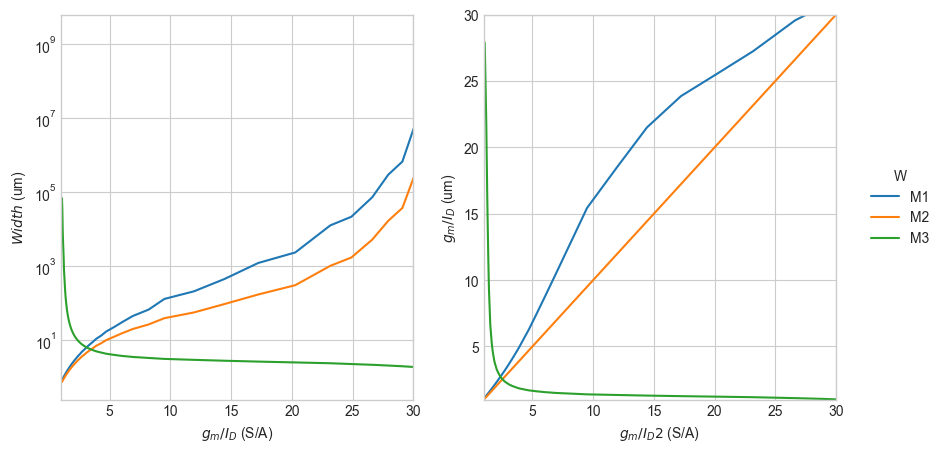

In [4]:
L12 = d['L12']
VDD = s['VDD']
ID = s['ID']
VR = s['VR']

#Plot of AV0 and FT versus gm/id

VGS2 = np.linspace(VR*1.2, VDD*0.8, 50)

JD2 = np.diag(nmos4.look_up('ID_W', VGS = VGS2, VDS=VGS2, L=L12))
JD1 = np.diag(nmos4.look_up('ID_W', VGS = VGS2-VR, VDS=VGS2-VR, L=L12))
JD3 = np.diag(pmos4.look_up('ID_W', VGS = VDD-VGS2, VDS=VDD-VGS2, L=L12))

gm_ID2 = np.diag(nmos4.look_up('GM_ID',VGS = VGS2, VDS=VGS2, L=L12))
gm_ID1 = np.diag(nmos4.look_up('GM_ID', VGS = VGS2-VR, VDS=VGS2-VR, L=L12))
gm_ID3 = np.diag(pmos4.look_up('GM_ID', VGS = VDD-VGS2, VDS=VDD-VGS2, L=L12))

W2 = ID / JD2
W1 = ID / JD1
W3 = ID / JD3

#Plot of AV0 and FT versus gm/id
plt.style.use("seaborn-v0_8-whitegrid")

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10, 5))
ax1.semilogy(gm_ID2, W1)
ax1.semilogy(gm_ID2, W2)
ax1.semilogy(gm_ID2, W3)
ax1.set_xlim(1, 30)
ax1.set_xlabel('$g_m/I_D$ (S/A)')
ax1.set_ylabel(r'$Width$ (um)')

#Plot of AV0 and FT versus gm/id
ax2.plot(gm_ID2, gm_ID1)
ax2.plot(gm_ID2, gm_ID2)
ax2.plot(gm_ID2, gm_ID3)
ax2.set_ylim(1, 30)
ax2.set_xlim(1, 30)
ax2.set_xlabel('$g_m/I_D2$ (S/A)')
ax2.set_ylabel(r'$g_m/I_D$ (um)')
plt.style.use("seaborn-v0_8-whitegrid")

#ax2 = ax1.twinx()
#ax2.semilogy(gmid_test, AV0.transpose(),linestyle='--')
#plt.ylabel(r'$AV_0/$ (V/V)')
ax2.legend(loc='center right', bbox_to_anchor=(1.3, 0.5), title='W', labels=['M1', 'M2', 'M3'])

plt.show()


# Intrerface trial

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── Style helpers ──────────────────────────────────────────────────────────────
_LABEL_STYLE   = {'description_width': '80px'}
_SLIDER_LAYOUT = widgets.Layout(width='320px')
_BOX_LAYOUT    = widgets.Layout(
    border='1px solid #dee2e6',
    border_radius='8px',
    padding='12px 16px',
    margin='6px',
    background="#0053a7",
)

# ── Widgets for s ──────────────────────────────────────────────────────────────
w_VDD = widgets.FloatSlider(
    value=2.7, min=1.0, max=5.0, step=0.1,
    description='VDD (V)', continuous_update=False,
    style=_LABEL_STYLE, layout=_SLIDER_LAYOUT,
    readout_format='.2f',
)
w_ID = widgets.FloatLogSlider(
    value=50, base=10, min=-1, max=3, step=0.01,   # en µA : 0.1 µA → 1000 µA
    description='ID (µA)', continuous_update=False,
    style=_LABEL_STYLE, layout=_SLIDER_LAYOUT,
    readout_format='.2f',
)
w_VR = widgets.FloatSlider(
    value=0.1, min=0.1, max=1.0, step=0.1,
    description='VR (V)', continuous_update=False,
    style=_LABEL_STYLE, layout=_SLIDER_LAYOUT,
    readout_format='.3f',
)

# ── Widgets for d ──────────────────────────────────────────────────────────────
w_L12 = widgets.FloatSlider(
    value=2.0, min=0.35, max=10.0, step=0.35,
    description='L12 (µm)', continuous_update=False,
    style=_LABEL_STYLE, layout=_SLIDER_LAYOUT,
    readout_format='.2f',
)

# ── Output area & status ───────────────────────────────────────────────────────
out        = widgets.Output()
status_lbl = widgets.Label(value='')

# ── Core run function ──────────────────────────────────────────────────────────
def run_design(change=None):
    s = {
        'VDD': w_VDD.value,
        'ID':  w_ID.value * 1e-6,   # µA → A
        'VR':  w_VR.value,
    }
    d = {
        'L12': w_L12.value,
    }
    status_lbl.value = '⏳ Running…'
    with out:
        clear_output(wait=True)
        try:
            m1, m2, m3 = adri.constant_gm_bias(nmos4, pmos4, s, d)
            adri.print_design_summary(s, d, {}, {}, m1, m2, m3)
            status_lbl.value = '✅ Done'
        except Exception as e:
            print(f'❌ Error: {e}')
            status_lbl.value = '❌ Error – see output'

# ── Attach observer to every slider ───────────────────────────────────────────
for w in [w_VDD, w_ID, w_VR, w_L12]:
    w.observe(run_design, names='value')

# ── Layout ─────────────────────────────────────────────────────────────────────
s_box = widgets.VBox(
    [widgets.HTML('<b style="font-size:13px">📐 Design Spec  <code>s</code></b>'),
     w_VDD, w_ID, w_VR],
    layout=_BOX_LAYOUT,
)
d_box = widgets.VBox(
    [widgets.HTML('<b style="font-size:13px">📏 Design Params  <code>d</code></b>'),
     w_L12],
    layout=_BOX_LAYOUT,
)

ui = widgets.VBox([
    widgets.HTML('<h3 style="margin:0 0 8px">🔧 Constant-G<sub>m</sub> Bias Designer</h3>'),
    widgets.HBox([s_box, d_box]),
    status_lbl,
    out,
])

display(ui)
run_design()   # run once on load with default values